In [20]:
import tensorflow as tf
from student_model import build_student_model
from tensorflow.keras.datasets import cifar10

In [21]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [22]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train,y_train,test_size = 0.2, random_state = 41, stratify = y_train)

In [24]:
input_shape = x_train.shape[1:]
input_shape

(32, 32, 3)

In [25]:
student_model = build_student_model(input_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        81,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,074 (687.79 KB)

 Trainable params: 175,626 (686.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
from tensorflow.keras.models import load_model

teacher_model = load_model('teacher_model.h5')
teacher_model.trainable = False
student_model.trainable = True


In [27]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import KLDivergence
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

temperature = 5
alpha = 0.2
batch_size = 256

steps_per_epoch = len(x_train) // batch_size

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=steps_per_epoch * 15,
    decay_rate=0.8,
    staircase=True
)

augmented_data = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
#augmented_data.fit(x_train)
#train_augmented = augmented_data.flow(x_train, y_train, batch_size=batch_size)

ce_loss = SparseCategoricalCrossentropy(from_logits = True)
kl_loss = KLDivergence()
optimizer = Adam(learning_rate=lr_schedule)


train_dataset = tf.data.Dataset.from_tensor_slices((x_train,y_train))
train_dataset = train_dataset.shuffle(len(x_train), reshuffle_each_iteration = True).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val,y_val))
val_dataset = val_dataset.batch(batch_size)

history = {

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [28]:
epochs = 80


for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss_metric = tf.keras.metrics.Mean()
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_batch,y_batch in train_dataset:
        with tf.GradientTape() as tape:
            student_logits = student_model(x_batch, training=True)
            teacher_logits = teacher_model(x_batch, training=False)

            hard_loss = ce_loss(y_batch, student_logits)

            teacher_soft = tf.nn.softmax(teacher_logits / temperature, axis=1)
            student_soft = tf.nn.softmax(student_logits / temperature, axis=1)
            soft_loss = kl_loss(teacher_soft, student_soft) * (temperature ** 2)

            loss = alpha * hard_loss + (1 - alpha) * soft_loss

        gradients = tape.gradient(loss, student_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, student_model.trainable_variables))

        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(y_batch, student_logits)

    train_loss = train_loss_metric.result().numpy()
    train_acc = train_acc_metric.result().numpy()


    val_loss_metric = tf.keras.metrics.Mean()
    val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_val_batch, y_val_batch in val_dataset:
        val_logits = student_model(x_val_batch, training=False)

        val_loss_batch = ce_loss(y_val_batch, val_logits)
        val_loss_metric.update_state(val_loss_batch)
        val_acc_metric.update_state(y_val_batch, val_logits)

    val_loss = val_loss_metric.result().numpy()
    val_acc = val_acc_metric.result().numpy()


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Loss: {train_loss:.4f} - Accuracy: {train_acc:.4f} - Validation Loss: {val_loss:.4f} - Validation Accuracy: {val_acc:.4f}\n")
    current_lr = optimizer.learning_rate
    print(f"Learning rate: {current_lr:.6f}")

Epoch 1/80
Loss: 16.7964 - Accuracy: 0.4837 - Validation Loss: 6.3543 - Validation Accuracy: 0.1737

Learning rate: 0.001000
Epoch 2/80
Loss: 11.8065 - Accuracy: 0.6169 - Validation Loss: 8.6655 - Validation Accuracy: 0.2418

Learning rate: 0.001000
Epoch 3/80
Loss: 9.9280 - Accuracy: 0.6718 - Validation Loss: 5.7406 - Validation Accuracy: 0.3958

Learning rate: 0.001000
Epoch 4/80
Loss: 8.8461 - Accuracy: 0.7009 - Validation Loss: 1.6999 - Validation Accuracy: 0.6794

Learning rate: 0.001000
Epoch 5/80
Loss: 8.0748 - Accuracy: 0.7245 - Validation Loss: 2.0155 - Validation Accuracy: 0.6834

Learning rate: 0.001000
Epoch 6/80
Loss: 7.5756 - Accuracy: 0.7381 - Validation Loss: 1.7336 - Validation Accuracy: 0.7061

Learning rate: 0.001000
Epoch 7/80
Loss: 7.1471 - Accuracy: 0.7496 - Validation Loss: 1.3223 - Validation Accuracy: 0.7466

Learning rate: 0.001000
Epoch 8/80
Loss: 6.7643 - Accuracy: 0.7612 - Validation Loss: 1.4191 - Validation Accuracy: 0.7406

Learning rate: 0.001000
Epoch 

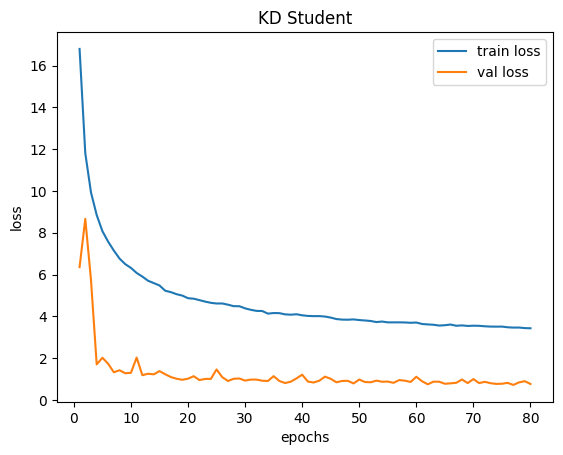

In [29]:
from matplotlib import pyplot as plt

epochs = range(1,len(history['train_loss'])+1)
plt.title('KD Student')
plt.plot(epochs, history['train_loss'])
plt.plot(epochs, history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train loss','val loss'])
plt.show()

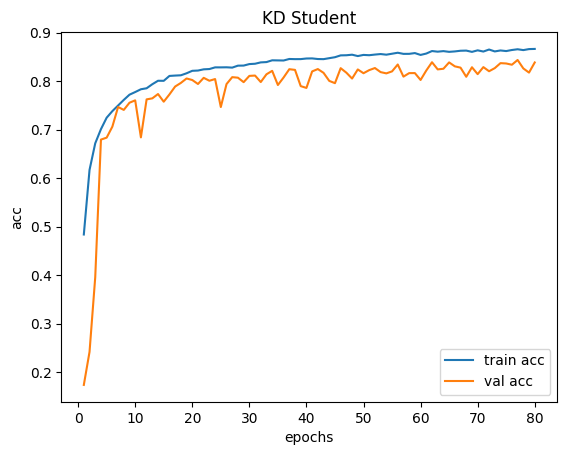

In [30]:
epochs = range(1,len(history['train_acc'])+1)
plt.title('KD Student')
plt.plot(epochs, history['train_acc'])
plt.plot(epochs, history['val_acc'])
plt.xlabel('epochs')
plt.ylabel('acc')
plt.legend(['train acc','val acc'])
plt.show()

In [31]:
test_dataset = tf.data.Dataset.from_tensor_slices((x_test.astype('float32'), y_test))
test_dataset = test_dataset.batch(256)

test_acc = tf.keras.metrics.SparseCategoricalAccuracy()
test_loss = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=True)

for x_batch, y_batch in test_dataset:
    predictions = student_model(x_batch, training=False)
    test_acc.update_state(y_batch, predictions)
    test_loss.update_state(y_batch, predictions)


print(f"Accuracy: {test_acc.result():.4f}")
print(f"Loss: {test_loss.result():.4f}")

Accuracy: 0.8279
Loss: 0.8099


In [32]:
student_model.save('student_model.h5')

In [33]:
self_taught_student = build_student_model(input_shape)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        81,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,074 (687.79 KB)

 Trainable params: 175,626 (686.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
self_taught_student.compile(optimizer = Adam(learning_rate=lr_schedule), loss = SparseCategoricalCrossentropy(from_logits = True),metrics = ['accuracy'])

In [35]:
sts_history = self_taught_student.fit(x_train,y_train,epochs=80,batch_size=batch_size,validation_data=(x_val,y_val))

Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.3522 - loss: 2.2704 - val_accuracy: 0.1089 - val_loss: 3.1048
Epoch 2/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5327 - loss: 1.4934 - val_accuracy: 0.1508 - val_loss: 3.8663
Epoch 3/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5966 - loss: 1.2355 - val_accuracy: 0.3658 - val_loss: 2.4950
Epoch 4/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6456 - loss: 1.0681 - val_accuracy: 0.6072 - val_loss: 1.1893
Epoch 5/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6795 - loss: 0.9609 - val_accuracy: 0.6267 - val_loss: 1.1991
Epoch 6/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6962 - loss: 0.8998 - val_accuracy: 0.6454 - val_loss: 1.1526
Epoch 7/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7190 - loss: 0.8345 - val_accuracy: 0.7081 - val_loss: 0.8851
Epoch 8/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7308 - loss: 0.7857 - val_acc

In [36]:
self_taught_student.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7918 - loss: 0.7603


[0.7553018927574158, 0.7943999767303467]

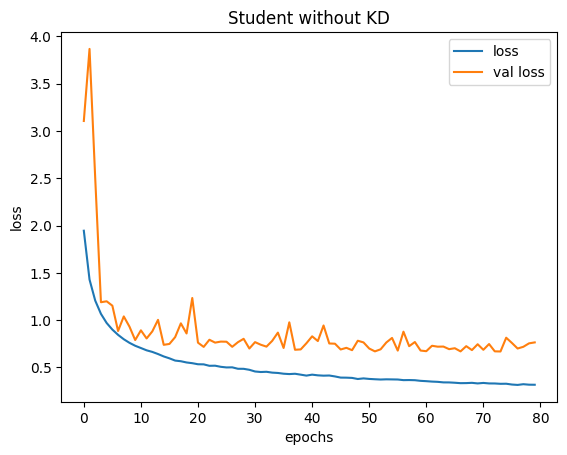

In [37]:
epochs = sts_history.epoch
plt.title('Student without KD')
plt.plot(epochs, sts_history.history['loss'])
plt.plot(epochs, sts_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['loss','val loss'])
plt.show()

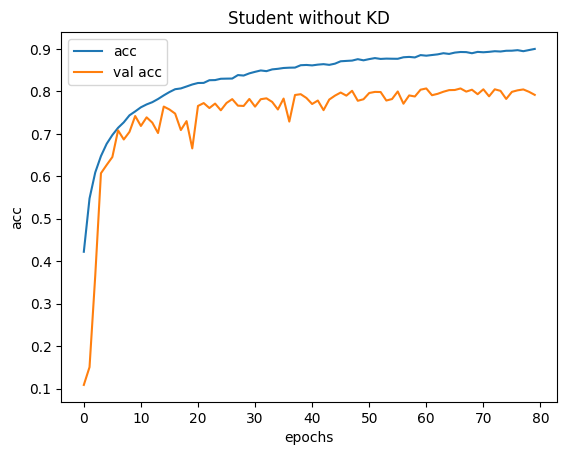

In [38]:
epochs = sts_history.epoch
plt.title('Student without KD')
plt.plot(epochs, sts_history.history['accuracy'])
plt.plot(epochs, sts_history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('acc')
plt.legend(['acc','val acc'])
plt.show()